# Sigprofiler plots SJD + TARGET + STJUDE

In [1]:
import pandas as pd
import json
from tqdm.notebook import tqdm
import pybedtools
pd.set_option('display.max_columns', 500)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
tumors_dict = {'tumor1':'t1','tumor2':'t2'}

target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
target_dict = {pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))

pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = sjd_dict | target_dict | stjude_dict | pmc_dict
pts = samples_dict.keys()

samples_final_ids_dict = json.load(open('sample_ids/sample_ids_final.json','rb'))

In [3]:
samples2_dict = {samples_dict[pt][tumor]:tumor for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor != 'sex'}
samples_list = [pt+'_'+tumor[0]+tumor[-1] for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor not in ['normal','normal2','sex']]
samples_list = [pt if pt.startswith('pt') | pt.startswith('PMC') else pt.split('_t')[0] for pt in samples_list]
samples_list

['pt1_t1',
 'pt1_t2',
 'pt3_t1',
 'pt3_t2',
 'pt3_c1',
 'pt3_c2',
 'pt4_t1',
 'pt4_t2',
 'pt5_t1',
 'pt5_t2',
 'pt6_t1',
 'pt6_t2',
 'pt6_c1',
 'pt6_c2',
 'pt7_t1',
 'pt8_t1',
 'pt9_t1',
 'pt9_t2',
 'pt11_t1',
 'pt12_t1',
 'pt12_t2',
 'pt13_t1',
 'pt14_t1',
 'pt14_t2',
 'pt14_c1',
 'pt14_c2',
 'pt15_t1',
 'pt16_t1',
 'pt17_t1',
 'pt18_t1',
 'pt18_t2',
 'pt19_t1',
 'pt20_t1',
 'PABKLN',
 'PADWRZ',
 'PADYZI',
 'PAEHIP',
 'PAJLWM',
 'PAJMBW',
 'PAJMRB',
 'PAJNER',
 'PAJNFP',
 'PAJNFZ',
 'PAKHTL',
 'PAKLYZ',
 'PAKTCT',
 'PARECB',
 'PAREWI',
 'PARGRN',
 'PARIRN',
 'PARPFY',
 'PARRCL',
 'PARTKH',
 'PARUGK',
 'PARZBI',
 'PARZRH',
 'PASABD',
 'PASADZ',
 'PASCDH',
 'PASDLA',
 'PASGCL',
 'PASRHU',
 'PASVDP',
 'PASWZZ',
 'PASXNA',
 'PASYNF',
 'PASZYE',
 'PATAFT',
 'PATBLF',
 'PATDVL',
 'PATENH',
 'PATFXW',
 'PATFZZ',
 'PATXEE',
 'PATXKA',
 'PAUCGJ',
 'PAUDPV',
 'PAUEKW',
 'PAUFVP',
 'PAUGYZ',
 'PAUHAZ',
 'PAUNPA',
 'PAVCKS',
 'PAVITI',
 'PAVYDM',
 'PAVYKD',
 'PAWDGA',
 'PAWFBL',
 'PAWFWK',
 'SJ01

## Prepare tables for input SigProfiler assignment

## Results Sigprofiler extractor

In [4]:
sbs_color_dict = {'SBS1':'orange',
                 'SBS2':'olive',
                 'SBS3':'mediumpurple',
                 'SBS5':'skyblue',
                 'SBS7a':'teal',
                 'SBS8':'goldenrod',
                 'SBS18':'royalblue',
                 'SBS12':'seagreen',
                 'SBS13':'purple',
                 'SBS17a':'green',
                 'SBS17b':'forestgreen',
                 'SBS31':'firebrick',
                 'SBS32':'plum',
                 'SBS35':'lightcoral',
                 'SBS40b':'turquoise',
                 'SBS45':'steelblue',
                 'SBS60':'darkseagreen',
                 'SBS84':'moccasin',
                 'SBS90':'violet'}
greys = ['gainsboro','lightgrey','lightgray','silver','darkgrey','darkgray','grey','gray','dimgrey','dimgray','slategrey']

def color_sigs (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in sbs_color_dict.keys():
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

def color_sigs2 (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in ['SBS31','SBS35']:
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

def change_name (sample,samples_dict,samples2_dict):
    tumor_id = sample.split('_vs_')[0]
    normal_id = sample.split('_vs_')[1]
    pt = [ pt for pt in samples_dict.keys() if samples_dict[pt]['normal']==normal_id]
    pt = pt[0]
    t = samples2_dict[tumor_id]
    if pt.startswith('pt') | pt.startswith('PMC'):
        sample2 = pt +'_'+t[0]+t[-1]
    else:
        sample2 = pt
    return sample2

ttmt_dict = {'AX4912':'naive',
            'AX4914':'naive',
            'AX4915':'StJude',
            'AX4916':'naive',
            'AX4918':'naive',
            'AX4919':'StJude',
            'AX4920':'Boston',
            'AX4921':'Boston',
            'AX4922':'COG',
            'AX4930':'naive',
            'AX4924':'naive',
            'AX4925':'mP6',
            'AX4926':'mP6',
            'AX4927':'EU-RHAB',
            'AX4928':'MSKCC',
            'AX4929':'MSKCC',
            'AX4923':'ifo/doxo/radio',
            'AX4931':'naive',
            'AX4932':'naive',
            'AX4933':'naive',
            'AX4934':'naive',
            'AX4935':'naive',
            'AX4936':'naive',
            'AX4937':'mP6',
            'AX4938':'naive',
            'AX4951':'naive',
            'AX4940':'mP6',
            'OMEN':'ifo/doxo/etop/vincr',
            'LN':'ifo/doxo/etop/vincr',
            'LNMETA':'ifo/doxo/etop/vincr',
            'DIAF':'ifo/doxo/etop/vincr'}


In [6]:
subset = 'allmuts'
df1 = pd.read_csv('signature_analysis/sigprofiler/extraction/analysis/'+subset+'/results/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Activities/COSMIC_SBS96_Activities.txt',sep='\t')
df1['Samples2'] = df1['Samples'].apply(lambda x: change_name(x,samples_dict,samples2_dict))
df1['ttmt'] = df1['Samples'].apply(lambda x: ttmt_dict[x.split('_vs_')[0]] if x.split('_vs_')[0] in ttmt_dict.keys() else None)
df1.index = df1['Samples2']
df1.drop(['Samples','Samples2'],inplace=True,axis=1)
df1 = df1.reindex(samples_list)

# excluded samples
excluded_sjd_samples = ['pt2_t1','pt9_t1','pt10_t1','pt14_t2','pt16_t1','pt20_t1']
bad_quality_samples = ['SJ032047','SJ033133']
xenograft = ['SJ063832']
no_age_data = ['SJ014754']
excluded_samples =  excluded_sjd_samples + bad_quality_samples + xenograft+ no_age_data

# samples_low_quality = ['pt9_t1','pt12_t1','pt14_t2','pt16_t1','pt20_t1','SJ032047','SJ063832','SJ033133']
# df1 = df1[~df1.index.isin(excluded_samples)]
# cols = [col for col in df1.columns if col not in ['SBS46','SBS57','SBS90']]
# df = df1[cols]
df1

,SBS1,SBS2,SBS5,SBS8,SBS13,SBS17a,SBS17b,SBS18,SBS31,SBS35,SBS36,SBS46,SBS57,SBS84,SBS90,ttmt
Samples2,,,,,,,,,,,,,,,,
pt1_t1,258,0,1654,0,0,0,0,0,0,0,0,0,0,0,0,naive
pt1_t2,228,0,1281,0,0,0,0,274,0,0,0,0,0,0,0,mP6
pt3_t1,109,0,489,0,0,0,0,139,0,0,0,0,145,0,74,naive
pt3_t2,170,0,2106,0,0,0,0,0,0,1196,0,0,0,0,0,StJude
pt3_c1,13,0,2893,0,0,0,0,1950,0,0,0,0,0,0,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJ063832,821,0,11183,0,0,0,0,0,2147,0,0,3426,0,0,0,None
PMC01_t1,144,0,1306,547,0,0,0,0,312,0,0,0,0,0,0,ifo/doxo/etop/vincr
PMC01_t2,140,0,911,0,0,0,0,205,0,269,0,0,0,0,0,ifo/doxo/etop/vincr


In [7]:
df1[df1.index=='pt18_t1']

,SBS1,SBS2,SBS5,SBS8,SBS13,SBS17a,SBS17b,SBS18,SBS31,SBS35,SBS36,SBS46,SBS57,SBS84,SBS90,ttmt
Samples2,,,,,,,,,,,,,,,,
pt18_t1,16,0,1130,0,0,0,0,0,0,0,0,0,0,0,0,naive


In [8]:
sigs = [col for col in df1.columns if col.startswith('SBS')]
sample_sigs_dict = {}
for sample in samples_list:
    sample_sigs = []
    sample_df = df1[df1.index==sample]
    if len(sample_df) != 0:
    	for sig in sigs:
         if sample_df[sig][0] != 0:
             sample_sigs.append(sig)
             sample_sigs_dict[sample] = sample_sigs
sample_sigs_dict

/tmp/ipykernel_522778/3548455293.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if sample_df[sig][0] != 0:


{'pt1_t1': ['SBS1', 'SBS5'],
 'pt1_t2': ['SBS1', 'SBS5', 'SBS18'],
 'pt3_t1': ['SBS1', 'SBS5', 'SBS18', 'SBS57', 'SBS90'],
 'pt3_t2': ['SBS1', 'SBS5', 'SBS35'],
 'pt3_c1': ['SBS1', 'SBS5', 'SBS18'],
 'pt3_c2': ['SBS1', 'SBS5', 'SBS18'],
 'pt4_t1': ['SBS1', 'SBS5', 'SBS18', 'SBS57', 'SBS90'],
 'pt4_t2': ['SBS1', 'SBS5', 'SBS18'],
 'pt5_t1': ['SBS1', 'SBS5', 'SBS17a', 'SBS17b', 'SBS18'],
 'pt5_t2': ['SBS1', 'SBS2', 'SBS5', 'SBS13', 'SBS17a', 'SBS17b', 'SBS18'],
 'pt6_t1': ['SBS1', 'SBS2', 'SBS5', 'SBS13', 'SBS18'],
 'pt6_t2': ['SBS1', 'SBS2', 'SBS5', 'SBS13', 'SBS18', 'SBS57'],
 'pt6_c1': ['SBS1', 'SBS5', 'SBS18'],
 'pt6_c2': ['SBS1', 'SBS5', 'SBS18'],
 'pt7_t1': ['SBS1', 'SBS5', 'SBS31', 'SBS35'],
 'pt8_t1': ['SBS1', 'SBS2', 'SBS5', 'SBS13', 'SBS18', 'SBS57', 'SBS90'],
 'pt9_t1': ['SBS1', 'SBS5', 'SBS57', 'SBS90'],
 'pt9_t2': ['SBS1', 'SBS5', 'SBS57', 'SBS90'],
 'pt11_t1': ['SBS1', 'SBS5'],
 'pt12_t1': ['SBS1', 'SBS5', 'SBS57', 'SBS90'],
 'pt12_t2': ['SBS1', 'SBS5', 'SBS8'],
 'pt13_t1':

In [9]:
sample_sigs_dict.keys()

dict_keys(['pt1_t1', 'pt1_t2', 'pt3_t1', 'pt3_t2', 'pt3_c1', 'pt3_c2', 'pt4_t1', 'pt4_t2', 'pt5_t1', 'pt5_t2', 'pt6_t1', 'pt6_t2', 'pt6_c1', 'pt6_c2', 'pt7_t1', 'pt8_t1', 'pt9_t1', 'pt9_t2', 'pt11_t1', 'pt12_t1', 'pt12_t2', 'pt13_t1', 'pt14_t1', 'pt14_t2', 'pt14_c1', 'pt14_c2', 'pt15_t1', 'pt16_t1', 'pt17_t1', 'pt18_t1', 'pt18_t2', 'pt19_t1', 'pt20_t1', 'PABKLN', 'PADWRZ', 'PADYZI', 'PAEHIP', 'PAJLWM', 'PAJMBW', 'PAJMRB', 'PAJNER', 'PAJNFP', 'PAJNFZ', 'PAKHTL', 'PAKLYZ', 'PAKTCT', 'PARECB', 'PAREWI', 'PARGRN', 'PARIRN', 'PARPFY', 'PARRCL', 'PARTKH', 'PARUGK', 'PARZBI', 'PARZRH', 'PASABD', 'PASADZ', 'PASCDH', 'PASDLA', 'PASGCL', 'PASRHU', 'PASVDP', 'PASWZZ', 'PASXNA', 'PASYNF', 'PASZYE', 'PATAFT', 'PATBLF', 'PATDVL', 'PATENH', 'PATFXW', 'PATFZZ', 'PATXEE', 'PATXKA', 'PAUCGJ', 'PAUDPV', 'PAUEKW', 'PAUFVP', 'PAUGYZ', 'PAUHAZ', 'PAUNPA', 'PAVCKS', 'PAVITI', 'PAVYDM', 'PAVYKD', 'PAWDGA', 'PAWFBL', 'PAWFWK', 'SJ014754', 'SJ015723', 'SJ030128', 'SJ030255', 'SJ030581', 'SJ030707', 'SJ030896', 

In [10]:
cosmic_df = pd.read_csv('signature_analysis/COSMIC_v3.4_SBS_GRCh38.txt',sep='\t')
cosmic_df

,Type,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,SBS7d,SBS8,SBS9,SBS10a,SBS10b,SBS10c,SBS10d,SBS11,SBS12,SBS13,SBS14,SBS15,SBS16,SBS17a,SBS17b,SBS18,SBS19,SBS20,SBS21,SBS22a,SBS22b,SBS23,SBS24,SBS25,SBS26,SBS27,SBS28,SBS29,SBS30,SBS31,SBS32,SBS33,SBS34,SBS35,SBS36,SBS37,SBS38,SBS39,SBS40a,SBS40b,SBS40c,SBS41,SBS42,SBS43,SBS44,SBS45,SBS46,SBS47,SBS48,SBS49,SBS50,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60,SBS84,SBS85,SBS86,SBS87,SBS88,SBS89,SBS90,SBS91,SBS92,SBS93,SBS94,SBS95,SBS96,SBS97,SBS98,SBS99
0,A[C>A]A,8.760226e-04,5.789892e-07,0.020920,0.042451,0.012052,0.000425,6.712587e-05,0.002344,0.004841,0.000040,4.431064e-02,0.000561,2.185262e-03,0.000181,0.004343,0.010125,0.000147,0.004542,1.816879e-03,1.126093e-03,0.000946,0.016094,2.072799e-03,0.000608,0.051688,0.001280,6.242471e-04,1.577225e-04,6.079509e-03,0.006129,8.445069e-04,0.036624,0.009936,0.000877,0.005245,0.000786,0.063498,0.001811,0.009609,0.022379,0.003115,4.914517e-03,0.008899,0.025257,0.003963,0.012902,0.011748,0.036537,0.014059,0.003776,0.002120,0.001171,0.029584,7.723217e-18,0.009178,0.004412,0.068160,8.464570e-04,0.025220,0.119346,0.141438,0.015188,0.005415,0.002170,0.005899,0.012606,0.012329,0.058965,3.616718e-03,6.163154e-03,3.500240e-03,0.006108,0.002968,0.008946,1.004268e-18,0.032297,0.002222,0.002934,0.011396,0.011628,0.015677,0.038614,0.011463,0.008222,0.008776,0.000004
1,A[C>A]C,2.220120e-03,1.455043e-04,0.016343,0.032990,0.009337,0.000516,1.767296e-04,0.000457,0.001135,0.000754,4.729956e-02,0.004047,1.739372e-03,0.006402,0.014643,0.018185,0.000549,0.001118,7.088422e-04,1.297141e-02,0.000491,0.002873,9.052935e-04,0.000127,0.015617,0.000636,1.380513e-03,2.334882e-03,9.357927e-05,0.003771,3.974198e-04,0.026258,0.006919,0.000522,0.004699,0.002497,0.050661,0.000501,0.018351,0.018580,0.002200,6.917052e-03,0.045853,0.008212,0.001433,0.010026,0.007070,0.016583,0.004665,0.006218,0.001207,0.020474,0.005827,1.485929e-04,0.002828,0.004641,0.029405,8.199633e-04,0.006956,0.125437,0.001670,0.006436,0.001943,0.000788,0.002025,0.015469,0.001412,0.006655,2.351410e-03,7.688209e-04,4.971448e-03,0.000871,0.003735,0.004490,9.890296e-19,0.017495,0.000704,0.052013,0.009653,0.008011,0.024523,0.017212,0.007675,0.007456,0.006645,0.000007
2,A[C>A]G,1.797268e-04,5.361706e-05,0.001808,0.016116,0.001908,0.000053,7.325781e-05,0.000192,0.000388,0.000257,4.767275e-03,0.000440,1.537130e-04,0.000055,0.000677,0.000747,0.000097,0.000557,2.706555e-04,4.264466e-04,0.000047,0.001054,4.894382e-05,0.000060,0.002505,0.000255,2.256746e-05,3.033185e-04,8.161555e-04,0.001013,1.023483e-07,0.015293,0.001494,0.000118,0.000809,0.000363,0.019811,0.000094,0.001717,0.004597,0.000426,5.391344e-05,0.001439,0.002306,0.001092,0.001967,0.002753,0.003864,0.001175,0.002084,0.000063,0.000035,0.000645,9.460004e-07,0.001717,0.000309,0.001425,2.623113e-04,0.007337,0.005943,0.004945,0.004248,0.039379,0.001692,0.000046,0.000212,0.003428,0.000848,1.469153e-04,2.294037e-16,4.686325e-04,0.000316,0.000398,0.006357,1.031355e-18,0.009971,0.000144,0.000209,0.004851,0.001817,0.001627,0.008632,0.002057,0.001423,0.033740,0.000053
3,A[C>A]T,1.265052e-03,9.758841e-05,0.012265,0.029663,0.006636,0.000180,2.485224e-04,0.000714,0.001964,0.004051,4.720459e-02,0.003063,1.695607e-02,0.000016,0.013156,0.014206,0.000268,0.001226,3.472572e-04,8.301435e-02,0.001112,0.010658,6.184968e-05,0.000456,0.021469,0.000575,1.249985e-03,6.235937e-04,1.738427e-03,0.003589,5.667931e-18,0.022126,0.004986,0.000621,0.002737,0.003977,0.035753,0.000559,0.006323,0.014645,0.001903,1.240720e-03,0.021759,0.017933,0.001855,0.008917,0.007427,0.015489,0.004969,0.008212,0.001336,0.008040,0.002075,5.811548e-03,0.009708,0.003408,0.011958,3.847403e-05,0.008005,0.083407,0.021257,0.009229,0.000017,0.000416,0.001173,0.023001,0.008657,0.005584,1.460176e-02,4.447616e-04,9.367620e-03,0.002728,0.003639,0.004941,1.737757e-03,0.020818,0.001771,0.000130,0.007800,0.008457,0.011141,0.023409,0.011838,0.006908,0.003744,0.000031
4,A[C>G]A,1.839055e-03,2.226114e-16

In [11]:

sample_sigs_df_dict = {}
for sample in samples_list:#[s for s in samples_list if s not in ['pt9_t1','pt14_t2','pt16_t1','pt20_t1','SJ014754','SJ032047','SJ033133','SJ063832']]:
    sigs = sample_sigs_dict[sample]
    sample_sigs_df = cosmic_df[['Type']+sigs]
    sample_sigs_df_dict[sample] = sample_sigs_df
sample_sigs_df_dict

{'pt1_t1':        Type          SBS1      SBS5
 0   A[C>A]A  8.760226e-04  0.012052
 1   A[C>A]C  2.220120e-03  0.009337
 2   A[C>A]G  1.797268e-04  0.001908
 3   A[C>A]T  1.265052e-03  0.006636
 4   A[C>G]A  1.839055e-03  0.010144
 ..      ...           ...       ...
 91  T[T>C]T  4.274202e-03  0.018550
 92  T[T>G]A  2.165026e-16  0.005149
 93  T[T>G]C  5.520354e-05  0.006677
 94  T[T>G]G  5.776134e-04  0.006984
 95  T[T>G]T  2.200872e-16  0.013536
 
 [96 rows x 3 columns],
 'pt1_t2':        Type          SBS1      SBS5     SBS18
 0   A[C>A]A  8.760226e-04  0.012052  0.051688
 1   A[C>A]C  2.220120e-03  0.009337  0.015617
 2   A[C>A]G  1.797268e-04  0.001908  0.002505
 3   A[C>A]T  1.265052e-03  0.006636  0.021469
 4   A[C>G]A  1.839055e-03  0.010144  0.001736
 ..      ...           ...       ...       ...
 91  T[T>C]T  4.274202e-03  0.018550  0.003377
 92  T[T>G]A  2.165026e-16  0.005149  0.000686
 93  T[T>G]C  5.520354e-05  0.006677  0.002136
 94  T[T>G]G  5.776134e-04  0.006984  0.

In [12]:
for sample in sample_sigs_df_dict.keys():
    df = sample_sigs_df_dict[sample]
    df.to_csv('signature_analysis/sigprofiler/fitting/sigs_for_fitting/'+sample+'_sigs.txt',sep='\t',index=None)

## Prepare matrices per sample

In [13]:
matrix_df = pd.read_csv('signature_analysis/sigprofiler/extraction/analysis/clonal/output/SBS/clonal.SBS96.all',sep='\t')
matrix_df = matrix_df[[col for col in matrix_df.columns if col!='HK_vs_BLOOD']]
samples3_dict = {}
samples4_dict = {}
for sample in samples_list:
    if sample.startswith('pt') | sample.startswith('PMC'):
        pt = sample.split('_')[0]
        if '_t' in sample:
            t = sample.split('_t')[1]
            tumor_id = samples_dict[pt]['tumor'+t]
        else:
            c = sample.split('_c')[1]
            tumor_id = samples_dict[pt]['clone'+c]
    else:
        pt = sample
        tumor_id = samples_dict[pt]['tumor1']
    normal_id = samples_dict[pt]['normal']
    sample_id = tumor_id + '_vs_' + normal_id
    samples3_dict[sample] = sample_id
    samples4_dict[sample_id] = sample
  
matrix_df = matrix_df.rename(columns=samples4_dict)
matrix_df

,MutationType,pt1_t1,pt3_t1,pt3_t2,pt4_t1,pt5_t1,pt6_t2,pt7_t1,pt15_t1,pt9_t1,pt9_t2,pt12_t1,pt13_t1,pt14_t1,pt14_t2,pt8_t1,pt16_t1,pt17_t1,pt18_t1,pt18_t2,pt19_t1,pt20_t1,pt1_t2,pt4_t2,pt12_t2,pt6_c1,pt6_c2,pt5_t2,pt6_t1,pt3_c1,pt3_c2,pt11_t1,pt14_c1,pt14_c2,PMC01_t1,PMC01_t4,PMC01_t3,PMC01_t2,PABKLN,PADWRZ,PADYZI,PAEHIP,PAJLWM,PAJMBW,PAJMRB,PAJNER,PAJNFP,PAJNFZ,PAKHTL,PAKLYZ,PAKTCT,PARECB,PAREWI,PARGRN,PARIRN,PARPFY,PARRCL,PARTKH,PARUGK,PARZBI,PARZRH,PASABD,PASADZ,PASCDH,PASDLA,PASGCL,PASRHU,PASVDP,PASWZZ,PASXNA,PASYNF,PASZYE,PATAFT,PATBLF,PATDVL,PATENH,PATFXW,PATFZZ,PATXEE,PATXKA,PAUCGJ,PAUDPV,PAUEKW,PAUFVP,PAUGYZ,PAUHAZ,PAUNPA,PAVCKS,PAVITI,PAVYDM,PAVYKD,PAWDGA,PAWFBL,PAWFWK,SJ030128,SJ030255,SJ030581,SJ030707,SJ030896,SJ030997,SJ031235,SJ031605,SJ031948,SJ032047,SJ032346,SJ032393,SJ032417,SJ033133,SJ033236,SJ034089,SJ034110,SJ014754,SJ015723,SJ063832
0,A[C>A]A,18,14,38,6,40,14,52,56,3,2,0,11,24,3,18,2,10,3,1,8,8,21,5,21,51,56,30,18,121,105,0,73,73,20,14,8,16,11,21,7,5,7,7,4,4,11,10,7,30,21,8,3,9,14,5,12,9,3,14,27,11,7,5,7,8,5,7,3,10,7,7,4,18,10,13,12,19,8,12,23,3,18,19,15,3,15,23,17,9,2,10,20,6,6,22,27,6,15,3,0,25,81,0,11,19,0,0,2,2,2,27,4,100
1,A[C>A]C,14,14,56,1,17,8,138,36,0,1,2,13,23,2,10,4,10,2,1,9,4,14,1,17,18,17,20,11,47,44,1,39,46,18,13,10,14,8,6,3,2,2,3,2,4,8,4,10,24,19,4,7,1,11,13,6,8,4,5,9,5,6,3,2,9,4,5,3,7,2,3,8,5,2,7,6,7,8,7,7,4,14,4,11,4,16,16,13,9,5,6,8,1,2,22,13,2,22,3,0,26,121,0,4,10,3,0,0,0,3,40,6,98
2,A[C>A]G,3,3,1,0,3,3,6,8,1,1,0,2,3,0,3,3,2,0,0,1,1,4,0,0,4,5,3,4,15,14,1,9,11,2,1,0,0,0,0,0,1,1,0,2,1,0,2,1,2,4,0,0,0,0,2,2,0,0,2,2,1,1,0,0,2,0,2,0,0,2,0,1,3,2,0,2,3,0,0,2,0,5,0,0,1,0,2,4,2,0,4,0,1,2,7,2,0,1,1,0,5,8,0,0,7,0,0,0,0,0,1,2,39
3,A[C>A]T,18,11,38,1,35,13,59,39,0,3,1,8,13,0,7,0,8,2,2,15,8,19,2,14,26,31,29,13,60,52,1,43,45,13,8,8,10,6,6,6,1,2,9,1,3,8,6,5,33,17,6,6,10,11,8,6,7,7,8,10,6,12,2,5,6,2,2,0,6,6,5,4,7,2,8,8,13,5,2,14,7,12,8,12,5,10,14,6,10,7,7,13,6,0,23,12,2,8,0,1,35,58,0,9,16,2,0,1,0,1,21,3,72
4,A[C>G]A,8,12,27,0,19,8,25,24,7,1,8,5,12,5,8,6,5,1,1,6,8,10,1,5,26,26,19,8,43,47,1,30,39,16,13,11,14,5,8,2,2,4,2,1,2,5,4,6,15,9,3,6,3,3,4,5,5,3,4,6,5,4,2,3,6,1,6,0,9,5,4,9,5,5,4,7,3,3,4,8,3,12,7,4,2,4,12,7,2,6,6,11,3,3,10,5,2,10,4,1,17,29,0,3,8,3,0,0,0,1,7,9,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,T[T>C]T,17,5,38,0,37,8,66,48,20,5,26,5,23,31,7,24,5,2,0,12,29,20,1,19,46,48,39,10,69,78,2,29,36,24,14,6,13,5,9,16,1,5,8,5,5,13,11,19,9,12,6,9,6,5,6,4,13,2,8,11,3,9,3,5,13,0,2,6,6,6,8,5,7,4,8,4,6,6,10,12,1,30,6,6,5,10,16,9,6,3,13,11,3,2,15,10,7,18,5,1,12,64,1,12,16,0,0,0,1,0,12,10,469
92,T[T>G]A,2,2,18,0,12,1,12,19,0,0,0,4,13,2,2,0,4,0,0,4,1,5,0,5,16,17,12,4,25,23,1,20,28,4,4,2,3,3,3,10,1,2,1,0,0,4,2,4,6,3,3,2,1,0,4,4,4,1,4,2,2,3,3,1,3,3,3,1,5,2,1,3,1,2,2,3,0,1,1,2,2,6,3,1,1,2,4,3,3,1,2,1,1,1,3,3,0,7,1,0,5,23,1,1,4,0,0,0,0,3,3,2,138
93,T[T>G]C,1,3,9,0,9,2,4,5,0,0,1,0,6,0,1,0,1,1,0,2,1,2,0,4,9,8,9,3,17,19,0,9,11,3,3,2,2,2,1,6,0,0,1,1,1,3,2,1,3,2,0,1,0,1,2,0,3,0,3,2,0,2,1,1,1,0,0,1,4,0,2,1,5,1,0,1,2,1,1,3,3,3,2,1,0,0,3,2,2,2,2,2,2,0,3,3,0,1,2,0,3,4,1,4,4,1,0,1,0,0,0,1,109
94,T[T>G]G,8,4,22,0,12,3,18,9,2,1,0,4,6,0,2,0,3,4,3,6,5,7,0,10,16,16,13,6,32,32,0,14,14,7,6,4,6,6,2,5,1,0,5,3,1,1,2,6,6,2,2,0,2,4,5,3,5,2,4,6,3,3,2,1,3,1,1,1,4,0,2,2,3,3,4,3,4,6,3,4,3,6,3,3,1,3,9,3,2,3,4,4,4,2,11,2,0,6,2,0,11,23,1,0,5,1,0,0,0,0,0,2,180


In [14]:
for sample in samples_list:
    matrix_df[['MutationType']+[sample]].to_csv('signature_analysis/sigprofiler/fitting/matrices_per_sample/'+sample+'.clonal.SBS96.txt',sep='\t',index=None)

In [15]:
matrix_df = pd.read_csv('signature_analysis/sigprofiler/extraction/analysis/subclonal/output/SBS/subclonal.SBS96.all',sep='\t')
matrix_df = matrix_df[[col for col in matrix_df.columns if col!='HK_vs_BLOOD']]
samples3_dict = {}
samples4_dict = {}
for sample in samples_list:
    if sample.startswith('pt') | sample.startswith('PMC'):
        pt = sample.split('_')[0]
        if '_t' in sample:
            t = sample.split('_t')[1]
            tumor_id = samples_dict[pt]['tumor'+t]
        else:
            c = sample.split('_c')[1]
            tumor_id = samples_dict[pt]['clone'+c]
    else:
        pt = sample
        tumor_id = samples_dict[pt]['tumor1']
    normal_id = samples_dict[pt]['normal']
    sample_id = tumor_id + '_vs_' + normal_id
    samples3_dict[sample] = sample_id
    samples4_dict[sample_id] = sample
  
matrix_df = matrix_df.rename(columns=samples4_dict)
matrix_df

,MutationType,pt1_t1,pt3_t1,pt3_t2,pt4_t1,pt5_t1,pt6_t2,pt7_t1,pt15_t1,pt9_t1,pt9_t2,pt12_t1,pt13_t1,pt14_t1,pt14_t2,pt8_t1,pt16_t1,pt17_t1,pt18_t1,pt18_t2,pt19_t1,pt20_t1,pt1_t2,pt4_t2,pt12_t2,pt6_c1,pt6_c2,pt5_t2,pt6_t1,pt3_c1,pt3_c2,pt11_t1,pt14_c1,pt14_c2,PMC01_t1,PMC01_t4,PMC01_t3,PMC01_t2,PABKLN,PADWRZ,PADYZI,PAEHIP,PAJLWM,PAJMBW,PAJMRB,PAJNER,PAJNFP,PAJNFZ,PAKHTL,PAKLYZ,PAKTCT,PARECB,PAREWI,PARGRN,PARIRN,PARPFY,PARRCL,PARTKH,PARUGK,PARZBI,PARZRH,PASABD,PASADZ,PASCDH,PASDLA,PASGCL,PASRHU,PASVDP,PASWZZ,PASXNA,PASYNF,PASZYE,PATAFT,PATBLF,PATDVL,PATENH,PATFXW,PATFZZ,PATXEE,PATXKA,PAUCGJ,PAUDPV,PAUEKW,PAUFVP,PAUGYZ,PAUHAZ,PAUNPA,PAVCKS,PAVITI,PAVYDM,PAVYKD,PAWDGA,PAWFBL,PAWFWK,SJ030128,SJ030255,SJ030581,SJ030707,SJ030896,SJ030997,SJ031235,SJ031605,SJ031948,SJ032047,SJ032346,SJ032393,SJ032417,SJ033133,SJ033236,SJ034089,SJ034110,SJ014754,SJ015723,SJ063832
0,A[C>A]A,7,2,7,6,3,10,0,1,0,11,0,7,2,0,11,0,7,2,9,13,0,5,1,1,2,2,12,2,12,3,1,15,11,16,34,24,4,0,0,9,4,1,0,0,0,8,0,1,11,1,0,3,4,1,0,0,0,0,0,2,4,0,6,1,0,0,0,2,0,0,0,2,0,0,1,2,4,2,0,0,0,1,1,2,4,0,1,0,0,2,0,2,3,1,3,1,0,0,0,2,53,16,0,0,21,2,0,0,1,2,2,8,0
1,A[C>A]C,5,2,6,1,1,3,0,3,0,6,0,14,4,0,8,0,3,14,3,36,0,4,2,3,0,1,5,2,6,4,8,6,3,20,30,13,9,0,0,2,2,0,0,0,0,4,0,1,1,1,0,2,2,1,4,0,0,0,0,1,0,0,1,0,0,0,1,3,0,0,0,1,0,0,0,0,0,4,0,0,0,1,0,3,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,52,21,0,1,24,7,0,0,0,1,1,6,0
2,A[C>A]G,0,2,1,0,0,0,0,3,0,4,0,2,3,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,2,1,1,0,1,1,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,3,1,0,0,1,1,0,0,0,0,1,1,0
3,A[C>A]T,0,4,5,2,0,5,0,0,0,11,0,2,2,0,9,0,4,14,2,24,0,6,4,0,2,0,9,0,12,3,3,9,2,12,17,12,4,0,1,2,1,1,0,0,0,3,0,1,3,0,0,0,5,0,2,0,0,0,0,1,2,0,3,1,0,0,2,2,1,0,0,1,0,0,1,3,2,6,0,0,0,0,1,2,5,0,1,0,0,0,0,0,3,0,5,0,0,0,1,0,46,15,0,1,11,5,0,0,1,2,7,5,0
4,A[C>G]A,6,3,8,11,6,6,0,6,0,9,0,11,10,0,7,0,11,9,14,15,0,3,1,0,0,1,5,0,4,1,6,1,3,9,18,8,3,0,0,1,1,0,0,0,0,1,0,0,3,2,0,1,0,1,4,0,0,0,0,0,0,1,3,0,0,0,0,1,0,0,0,0,0,1,1,0,1,3,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,2,1,0,0,0,0,0,36,13,0,1,10,0,0,0,0,1,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,T[T>C]T,28,33,33,28,19,38,0,22,0,38,0,39,29,0,31,0,33,27,23,38,0,0,1,1,3,1,9,3,5,6,9,9,3,14,40,18,11,0,0,4,2,1,0,0,0,2,0,0,3,2,0,0,3,1,2,0,0,0,0,1,0,1,4,1,0,0,1,1,0,0,0,1,0,0,1,2,2,0,0,0,0,2,4,1,2,0,1,0,0,1,0,0,0,1,1,0,0,0,0,4,19,29,0,1,12,3,0,0,0,4,6,4,0
92,T[T>G]A,3,0,1,5,2,3,0,1,0,4,0,8,0,0,0,0,1,8,1,5,0,3,0,0,3,0,2,0,5,4,2,1,0,5,15,7,3,0,0,1,0,0,0,0,0,3,0,0,1,0,0,0,1,3,0,0,0,0,0,0,1,0,2,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,3,1,9,12,0,0,3,0,0,0,0,1,2,2,0
93,T[T>G]C,1,0,1,1,0,2,0,0,0,3,0,1,1,0,2,0,0,1,0,3,0,0,0,0,0,0,2,0,2,1,1,2,4,2,6,5,1,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,4,4,0,0,0,1,0,0,0,0,0,1,0
94,T[T>G]G,1,1,3,3,1,6,0,1,0,1,0,4,0,0,1,0,0,4,3,6,0,1,1,0,0,0,3,0,5,2,4,4,2,10,20,5,4,0,0,1,1,0,0,0,0,0,0,0,1,2,0,2,3,2,1,0,0,0,0,0,0,0,3,0,0,0,0,0,2,0,0,4,0,0,1,1,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,16,9,0,1,7,3,0,0,0,0,1,1,1


In [16]:
for sample in samples_list:
    matrix_df[['MutationType']+[sample]].to_csv('signature_analysis/sigprofiler/fitting/matrices_per_sample/'+sample+'.subclonal.SBS96.txt',sep='\t',index=None)

## Prepare qmap

In [ ]:
commands = []
path = './signature_analysis/sigprofiler/fitting/'
python_script = './code/python_scripts/sigprofiler_assign.py'
for sample in samples_list:
    for subset in ['clonal','subclonal']:
        sample_file = path +'matrices_per_sample/'+ sample + '.'+subset+'.SBS96.txt'
        sigs_file = path + 'sigs_for_fitting/'+sample+'_sigs.txt'
        output = path + 'results/'+sample+'/'+subset+'/'
        command = 'python '+python_script+' --samples '+sample_file+' --output '+output+' --signature_database '+sigs_file
        commands.append(command)

In [18]:
qmap_pre_params = ['[pre]','. "/home/$USER/miniconda3/etc/profile.d/conda.sh"','conda activate sigprofiler','[params]','cores = 1','memory = 8G','[jobs]']
qmap_file = qmap_pre_params + commands

In [19]:
date = '260204'

In [20]:
commands

['python code/python_scripts/sigprofiler_assign.py --samples signature_analysis/sigprofiler/fitting/matrices_per_sample/pt1_t1.clonal.SBS96.txt --output signature_analysis/sigprofiler/fitting/results/pt1_t1/clonal/ --signature_database signature_analysis/sigprofiler/fitting/sigs_for_fitting/pt1_t1_sigs.txt',
 'python code/python_scripts/sigprofiler_assign.py --samples signature_analysis/sigprofiler/fitting/matrices_per_sample/pt1_t1.subclonal.SBS96.txt --output signature_analysis/sigprofiler/fitting/results/pt1_t1/subclonal/ --signature_database signature_analysis/sigprofiler/fitting/sigs_for_fitting/pt1_t1_sigs.txt',
 'python code/python_scripts/sigprofiler_assign.py --samples signature_analysis/sigprofiler/fitting/matrices_per_sample/pt1_t2.clonal.SBS96.txt --output signature_analysis/sigprofiler/fitting/results/pt1_t2/clonal/ --signature_database signature_analysis/sigprofiler/fitting/sigs_for_fitting/pt1_t2_sigs.txt',
 'python code/python_scripts/sigprofiler_assign.py --samples sig

In [23]:
#Save qmap file

with open('code/qmap_files/sigprofiler/'+date+'_sigprofiler_assignment.qmap', 'w') as f:
    for item in qmap_file:
        f.write('%s\n' % item)

## Results refitting / assignment

In [24]:
clonal_df = pd.DataFrame()
subclonal_df = pd.DataFrame()
for sample in samples_list:
    df1 = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    clonal_df = pd.concat([clonal_df,df1],ignore_index=True)
    df1 = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/subclonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    subclonal_df = pd.concat([subclonal_df,df1],ignore_index=True)

/tmp/ipykernel_522778/1070246196.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subclonal_df = pd.concat([subclonal_df,df1],ignore_index=True)
/tmp/ipykernel_522778/1070246196.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subclonal_df = pd.concat([subclonal_df,df1],ignore_index=True)
/tmp/ipykernel_522778/1070246196.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA c

In [25]:
clonal_df = clonal_df.fillna(0)
subclonal_df = subclonal_df.fillna(0)

In [26]:
tab_dict = json.load(open('clinical_data/tab_dict.json','rb'))
tab_dict

{'pt1_t1': 8.32,
 'pt1_t2': 8.56,
 'pt3_t1': 4.79,
 'pt3_t2': 6.16,
 'pt4_t1': 0.02,
 'pt4_t2': 0.03,
 'pt5_t1': 13.5,
 'pt5_t2': 13.7,
 'pt6_t1': 1.6,
 'pt6_t2': 1.64,
 'pt7_t1': 2.25,
 'pt8_t1': 3.02,
 'pt9_t1': 0.44,
 'pt9_t2': 0.49,
 'pt11_t1': 5.57,
 'pt12_t1': 0.68,
 'pt12_t2': 0.68,
 'pt13_t1': 0.53,
 'pt14_t1': 10.1,
 'pt14_t2': 10.5,
 'pt15_t1': 15.58,
 'pt16_t1': 1.67,
 'pt17_t1': 2.61,
 'pt18_t1': 0.01,
 'pt18_t2': 0.02,
 'pt19_t1': 1.13,
 'pt20_t1': 0.57,
 'PABKLN': 1.1,
 'PADWRZ': 1.05,
 'PADYCE': 2.28,
 'PADYZI': 2.97,
 'PAEHIP': 0.48,
 'PAJLRA': 0.01,
 'PAJLWM': 0.79,
 'PAJMBW': 0.39,
 'PAJMRB': 1.48,
 'PAJNER': 0.17,
 'PAJNFP': 0.96,
 'PAJNFZ': 1.62,
 'PAJPHJ': 0.95,
 'PAKHTL': 3.13,
 'PAKLYZ': 1.44,
 'PAKPEW': 2.6,
 'PAKTCT': 2.36,
 'PARECB': 0.38,
 'PAREWI': 0.84,
 'PARGRN': 0.4,
 'PARIRN': 4.02,
 'PARKKN': 6.45,
 'PARPFY': 0.99,
 'PARRCL': 0.59,
 'PARTKH': 0.73,
 'PARUGK': 0.6,
 'PARZBI': 1.44,
 'PARZRH': 1.67,
 'PASABD': 0.47,
 'PASADZ': 0.75,
 'PASAMZ': 8.29,
 'PAS

In [27]:
def add_age_and_total (df,tab_dict):
	col_sigs = [col for col in df.columns if 'SBS' in col]
	df['ttmt'] = df['Samples'].apply(lambda x: ttmt_dict[x.split('_vs_')[0]] if x.split('_vs_')[0] in ttmt_dict.keys() else None)
	df['total'] = df[col_sigs].sum(axis=1)
	df.index = df['Samples']
	df['age'] = df.index.map(tab_dict)
	#samples without age information
	display(df[df['age'].isnull()])
	#remove samples without age info
	df = df[~df['age'].isnull()]
	df = df.sort_values('age',ascending=True)
	df = df.drop(['total','Samples'],axis=1)
	return df

clonal1_df = add_age_and_total (clonal_df,tab_dict)	
subclonal1_df = add_age_and_total (subclonal_df,tab_dict)

,Samples,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18,ttmt,total,age
Samples,,,,,,,,,,,,,,,,,,
pt3_c1,pt3_c1,0.0,3091,0.0,0.0,0.0,1307.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,4398.0,NaN
pt3_c2,pt3_c2,0.0,3031,0.0,0.0,0.0,1261.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,4292.0,NaN
pt6_c1,pt6_c1,0.0,1651,0.0,0.0,0.0,359.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2010.0,NaN
pt6_c2,pt6_c2,0.0,1742,0.0,0.0,0.0,404.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2146.0,NaN
pt14_c1,pt14_c1,0.0,2336,0.0,0.0,0.0,606.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2942.0,NaN
pt14_c2,pt14_c2,0.0,2337,0.0,0.0,0.0,645.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2982.0,NaN
SJ014754,SJ014754,85.0,398,326.0,0.0,0.0,143.0,0.0,0.0,0.0,0.0,0.0,218.0,0.0,0.0,None,1170.0,NaN


,Samples,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18,ttmt,total,age
Samples,,,,,,,,,,,,,,,,,,
pt3_c1,pt3_c1,0,287,0.0,0.0,0.0,170.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,457.0,NaN
pt3_c2,pt3_c2,0,262,0.0,0.0,0.0,108.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,370.0,NaN
pt6_c1,pt6_c1,1,106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,107.0,NaN
pt6_c2,pt6_c2,4,65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,69.0,NaN
pt14_c1,pt14_c1,0,225,0.0,0.0,0.0,77.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,302.0,NaN
pt14_c2,pt14_c2,0,181,0.0,0.0,0.0,71.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,252.0,NaN
SJ014754,SJ014754,0,131,89.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,None,220.0,NaN


Text(0.92, -0.4, 'Age')

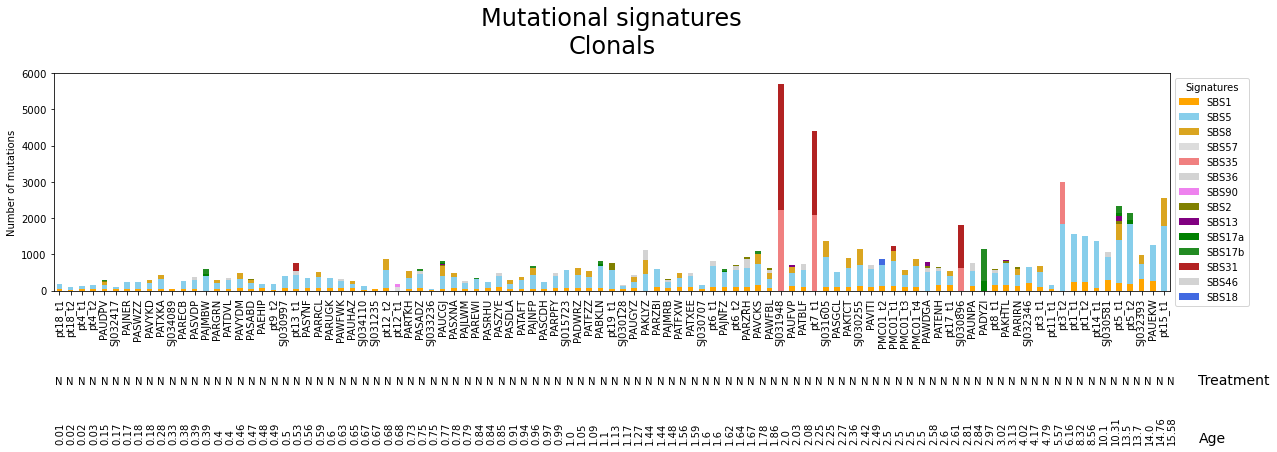

In [28]:
df = clonal1_df[~clonal1_df.index.isin(excluded_samples)]
col_sigs = [c for c in df.columns if c.startswith('SBS')]
colors_dict,colors_list = color_sigs(col_sigs)
df[col_sigs].plot.bar(stacked=True,figsize=(20,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Mutational signatures\nClonals',size=24,pad=20)
plt.ylim([0,6000])
plt.xlabel('')
plt.ylabel('Number of mutations')
plt.xticks(rotation=90)
ttmts = df['ttmt'].tolist()
n=0
for pt in df.index:
    ttmt = df['ttmt'][pt]
    age = df['age'][pt]
    #plot ttmt
    left_space = 0.126
    if ttmt == 'naive' or ttmt == None:
        plt.text(x=left_space+n,y=-0.2,s='N',rotation=0,color='k',transform=plt.gcf().transFigure)
    else:
        plt.text(x=left_space+n,y=-0.2,s='T',rotation=0,color='r',transform=plt.gcf().transFigure)
    #plot age
    plt.text(x=left_space+n,y=-0.4,s=str(age),rotation=90,color='k',transform=plt.gcf().transFigure)
        
    n = n+0.00788
plt.text(x=0.92,y=-0.2,s='Treatment',size=14,transform=plt.gcf().transFigure)
plt.text(x=0.92,y=-0.4,s='Age',size=14,transform=plt.gcf().transFigure)

In [29]:
col_sigs = ['SBS1','SBS5']
df['total'] = df[col_sigs].sum(axis=1)
df['age'] = df.index.map(tab_dict)
df = df.sort_values('age',ascending=True)
df = df.drop(['total'],axis=1)
aging_df = df[col_sigs+['ttmt']]

/tmp/ipykernel_522778/1344492417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total'] = df[col_sigs].sum(axis=1)
/tmp/ipykernel_522778/1344492417.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = df.index.map(tab_dict)


Text(0.92, -0.4, 'Age')

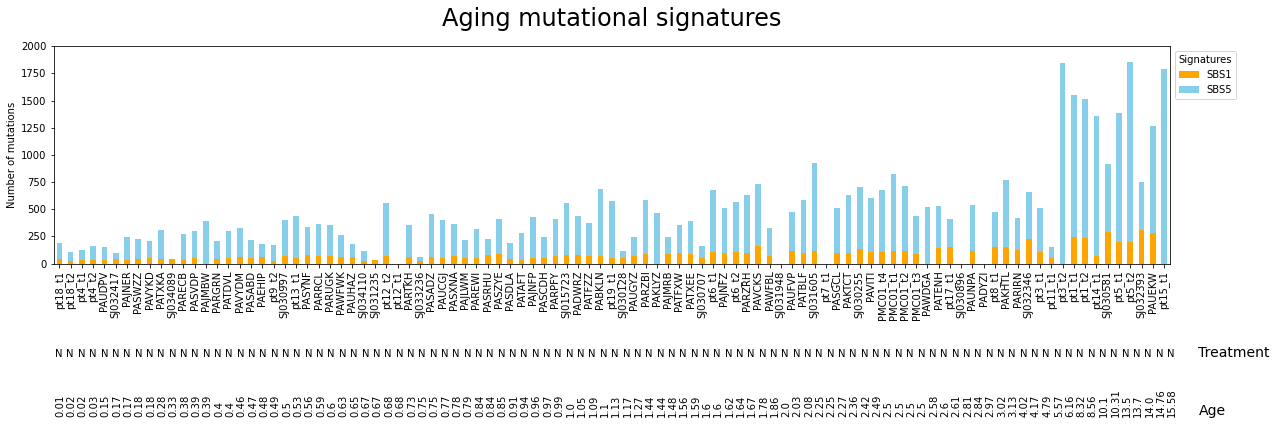

In [30]:
colors_dict,colors_list = color_sigs(col_sigs)
aging_df.plot.bar(stacked=True,figsize=(20,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Aging mutational signatures',size=24,pad=20)
plt.ylim([0,2000])
plt.xlabel('')
plt.ylabel('Number of mutations')
plt.xticks(rotation=90)
ttmts = aging_df['ttmt'].tolist()
n=0
for pt in df.index:
    ttmt = df['ttmt'][pt]
    age = df['age'][pt]
    #plot ttmt
    left_space = 0.126
    if ttmt == 'naive' or ttmt == None:
        plt.text(x=left_space+n,y=-0.2,s='N',rotation=0,color='k',transform=plt.gcf().transFigure)
    else:
        plt.text(x=left_space+n,y=-0.2,s='T',rotation=0,color='r',transform=plt.gcf().transFigure)
    #plot age
    plt.text(x=left_space+n,y=-0.4,s=str(age),rotation=90,color='k',transform=plt.gcf().transFigure)
        
    n = n+0.00788

plt.text(x=0.92,y=-0.2,s='Treatment',size=14,transform=plt.gcf().transFigure)
plt.text(x=0.92,y=-0.4,s='Age',size=14,transform=plt.gcf().transFigure)

## SBS1 mutational signature

Text(0.92, -0.4, 'Age')

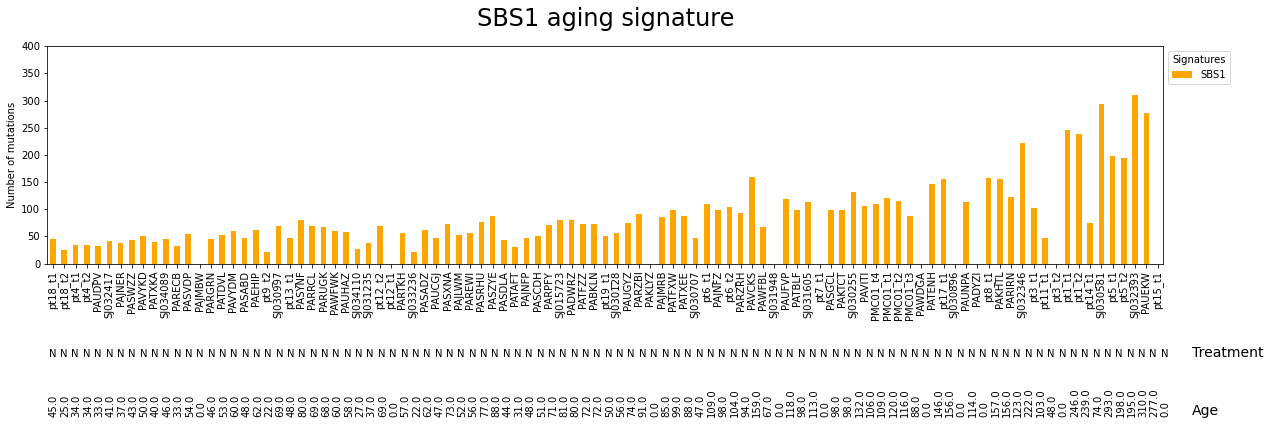

In [31]:
col_sigs = ['SBS1']
sbs1_df = df[col_sigs+['ttmt']]
colors_dict,colors_list = color_sigs(col_sigs)
sbs1_df.plot.bar(stacked=True,figsize=(20,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('SBS1 aging signature',size=24,pad=20)
plt.ylim([0,400])
plt.xlabel('')
plt.ylabel('Number of mutations')
plt.xticks(rotation=90)
ttmts = aging_df['ttmt'].tolist()
n=0
for pt in df.index:
    ttmt = df['ttmt'][pt]
    age = df['SBS1'][pt]
    #plot ttmt
    left_space = 0.126
    if ttmt == 'naive' or ttmt == None:
        plt.text(x=left_space+n,y=-0.2,s='N',rotation=0,color='k',transform=plt.gcf().transFigure)
    else:
        plt.text(x=left_space+n,y=-0.2,s='T',rotation=0,color='r',transform=plt.gcf().transFigure)
    #plot age
    plt.text(x=left_space+n,y=-0.4,s=str(age),rotation=90,color='k',transform=plt.gcf().transFigure)
        
    n = n+0.00788

plt.text(x=0.92,y=-0.2,s='Treatment',size=14,transform=plt.gcf().transFigure)
plt.text(x=0.92,y=-0.4,s='Age',size=14,transform=plt.gcf().transFigure)

## SBS5 mutational signature

Text(0.92, -0.4, 'Age')

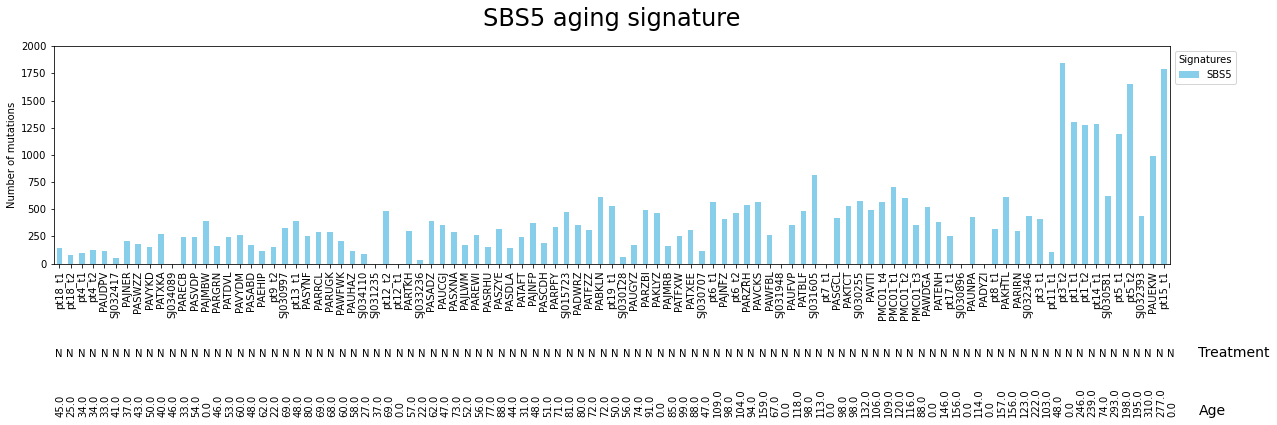

In [32]:
col_sigs = ['SBS5']
sbs5_df = df[col_sigs+['ttmt']]
colors_dict,colors_list = color_sigs(col_sigs)
sbs5_df.plot.bar(stacked=True,figsize=(20,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('SBS5 aging signature',size=24,pad=20)
plt.ylim([0,2000])
plt.xlabel('')
plt.ylabel('Number of mutations')
plt.xticks(rotation=90)
ttmts = aging_df['ttmt'].tolist()
n=0
for pt in df.index:
    ttmt = df['ttmt'][pt]
    age = df['SBS1'][pt]
    #plot ttmt
    left_space = 0.126
    if ttmt == 'naive' or ttmt == None:
        plt.text(x=left_space+n,y=-0.2,s='N',rotation=0,color='k',transform=plt.gcf().transFigure)
    else:
        plt.text(x=left_space+n,y=-0.2,s='T',rotation=0,color='r',transform=plt.gcf().transFigure)
    #plot age
    plt.text(x=left_space+n,y=-0.4,s=str(age),rotation=90,color='k',transform=plt.gcf().transFigure)
        
    n = n+0.00788

plt.text(x=0.92,y=-0.2,s='Treatment',size=14,transform=plt.gcf().transFigure)
plt.text(x=0.92,y=-0.4,s='Age',size=14,transform=plt.gcf().transFigure)

In [34]:
len(aging_df)

99

## Plot SJD paired samples and PMC case with multiple tumors

In [33]:
paired_dict = sjd_dict | pmc_dict

samples2_dict = {paired_dict[pt][tumor]:tumor for pt in paired_dict.keys() for tumor in paired_dict[pt].keys() if tumor != 'sex'}

def change_name (sample,samples_dict,samples2_dict):
    tumor_id = sample.split('_vs')[0]
    normal_id = sample.split('_vs_')[1]
    pt = [ pt for pt in samples_dict.keys() if samples_dict[pt]['normal']==normal_id]
    pt = pt[0]
    if tumor_id in samples2_dict.keys():
        t = samples2_dict[tumor_id]
        sample2 = pt +'_'+t[0]+t[-1]
    else:
        sample2 = tumor_id
    return sample2

In [35]:
paired_dict

{'pt1': {'normal': 'AX4894',
  'tumor1': 'AX4912',
  'tumor2': 'AX4937',
  'sex': 'male'},
 'pt3': {'normal': 'AX4895',
  'tumor1': 'AX4914',
  'tumor2': 'AX4915',
  'clone1': 'AX4946',
  'clone2': 'AX4947',
  'sex': 'male'},
 'pt4': {'normal': 'AX4896',
  'tumor1': 'AX4916',
  'tumor2': 'AX4938',
  'sex': 'female'},
 'pt5': {'normal': 'AX4897',
  'tumor1': 'AX4918',
  'tumor2': 'AX4944',
  'sex': 'male'},
 'pt6': {'normal': 'AX4898',
  'tumor1': 'AX4945',
  'tumor2': 'AX4921',
  'sex': 'male',
  'clone1': 'AX4942',
  'clone2': 'AX4943'},
 'pt7': {'normal': 'AX4899', 'tumor1': 'AX4922', 'sex': 'male'},
 'pt8': {'normal': 'AX4900', 'tumor1': 'AX4930', 'sex': 'male'},
 'pt9': {'normal': 'AX4901',
  'tumor1': 'AX4924',
  'tumor2': 'AX4925',
  'sex': 'female'},
 'pt11': {'normal': 'AX4903', 'tumor1': 'AX4951', 'sex': 'female'},
 'pt12': {'normal': 'AX4904',
  'tumor1': 'AX4926',
  'tumor2': 'AX4940',
  'sex': 'male'},
 'pt13': {'normal': 'AX4905', 'tumor1': 'AX4927', 'sex': 'male'},
 'pt14

In [36]:
tab_dict

{'pt1_t1': 8.32,
 'pt1_t2': 8.56,
 'pt3_t1': 4.79,
 'pt3_t2': 6.16,
 'pt4_t1': 0.02,
 'pt4_t2': 0.03,
 'pt5_t1': 13.5,
 'pt5_t2': 13.7,
 'pt6_t1': 1.6,
 'pt6_t2': 1.64,
 'pt7_t1': 2.25,
 'pt8_t1': 3.02,
 'pt9_t1': 0.44,
 'pt9_t2': 0.49,
 'pt11_t1': 5.57,
 'pt12_t1': 0.68,
 'pt12_t2': 0.68,
 'pt13_t1': 0.53,
 'pt14_t1': 10.1,
 'pt14_t2': 10.5,
 'pt15_t1': 15.58,
 'pt16_t1': 1.67,
 'pt17_t1': 2.61,
 'pt18_t1': 0.01,
 'pt18_t2': 0.02,
 'pt19_t1': 1.13,
 'pt20_t1': 0.57,
 'PABKLN': 1.1,
 'PADWRZ': 1.05,
 'PADYCE': 2.28,
 'PADYZI': 2.97,
 'PAEHIP': 0.48,
 'PAJLRA': 0.01,
 'PAJLWM': 0.79,
 'PAJMBW': 0.39,
 'PAJMRB': 1.48,
 'PAJNER': 0.17,
 'PAJNFP': 0.96,
 'PAJNFZ': 1.62,
 'PAJPHJ': 0.95,
 'PAKHTL': 3.13,
 'PAKLYZ': 1.44,
 'PAKPEW': 2.6,
 'PAKTCT': 2.36,
 'PARECB': 0.38,
 'PAREWI': 0.84,
 'PARGRN': 0.4,
 'PARIRN': 4.02,
 'PARKKN': 6.45,
 'PARPFY': 0.99,
 'PARRCL': 0.59,
 'PARTKH': 0.73,
 'PARUGK': 0.6,
 'PARZBI': 1.44,
 'PARZRH': 1.67,
 'PASABD': 0.47,
 'PASADZ': 0.75,
 'PASAMZ': 8.29,
 'PAS

In [37]:
paired_samples = [pt+'_t'+t[-1] for pt in paired_dict.keys() for t in paired_dict[pt].keys() if t not in ['sex','clone1','clone2','normal','normal2']]
paired_samples

['pt1_t1',
 'pt1_t2',
 'pt3_t1',
 'pt3_t2',
 'pt4_t1',
 'pt4_t2',
 'pt5_t1',
 'pt5_t2',
 'pt6_t1',
 'pt6_t2',
 'pt7_t1',
 'pt8_t1',
 'pt9_t1',
 'pt9_t2',
 'pt11_t1',
 'pt12_t1',
 'pt12_t2',
 'pt13_t1',
 'pt14_t1',
 'pt14_t2',
 'pt15_t1',
 'pt16_t1',
 'pt17_t1',
 'pt18_t1',
 'pt18_t2',
 'pt19_t1',
 'pt20_t1',
 'PMC01_t1',
 'PMC01_t2',
 'PMC01_t3',
 'PMC01_t4']

In [38]:
sbs_color_dict = {'SBS1':'orange',
                 'SBS2':'olive',
                 'SBS3':'mediumpurple',
                 'SBS5':'skyblue',
                 'SBS7a':'teal',
                 'SBS8':'goldenrod',
                 'SBS18':'royalblue',
                 'SBS12':'seagreen',
                 'SBS13':'purple',
                 'SBS17a':'green',
                 'SBS17b':'forestgreen',
                 'SBS31':'firebrick',
                 'SBS32':'plum',
                 'SBS35':'lightcoral',
                 'SBS40b':'turquoise',
                 'SBS45':'steelblue',
                 'SBS60':'darkseagreen',
                 'SBS84':'moccasin',
                 'SBS90':'plum'}
greys = ['gainsboro','lightgrey','lightgray','silver','darkgrey','darkgray','grey','gray','dimgrey','dimgray','slategrey']

def color_sigs (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in sbs_color_dict.keys():
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

In [39]:
clonal1_df = clonal_df.reindex(samples_list)
clonal1_df = clonal1_df[~clonal1_df.index.isin(excluded_samples)]
sbs_cols = [c for c in clonal1_df.columns if c.startswith('SBS')]
clonal1_df[sbs_cols] = clonal1_df[sbs_cols].fillna(0)
clonal1_df

,Samples,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18,ttmt,total,age
Samples,,,,,,,,,,,,,,,,,,
pt1_t1,pt1_t1,246.0,1305,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,1551.0,8.32
pt1_t2,pt1_t2,239.0,1273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,1512.0,8.56
pt3_t1,pt3_t1,103.0,409,174.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,686.0,4.79
pt3_t2,pt3_t2,0.0,1843,0.0,0.0,1145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2988.0,6.16
pt3_c1,pt3_c1,0.0,3091,0.0,0.0,0.0,1307.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,4398.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJ034110,SJ034110,27.0,92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,119.0,0.67
PMC01_t1,PMC01_t1,120.0,702,267.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,155.0,0.0,0.0,None,1244.0,2.50
PMC01_t2,PMC01_t2,116.0,599,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,None,867.0,2.50


In [40]:
subclonal1_df = subclonal1_df.reindex(samples_list)
subclonal1_df = subclonal1_df[~subclonal1_df.index.isin(excluded_samples)]
subclonal1_df

,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18,ttmt,age
Samples,,,,,,,,,,,,,,,,
pt1_t1,0.0,361.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,8.32
pt1_t2,0.0,271.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,8.56
pt3_t1,11.0,85.0,0.0,174.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,4.79
pt3_t2,21.0,462.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,6.16
pt3_c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJ034110,27.0,91.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.67
PMC01_t1,23.0,604.0,280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,158.0,0.0,0.0,None,2.50
PMC01_t2,29.0,428.0,0.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,2.50


In [42]:
df1 = pd.DataFrame()
df2 = pd.DataFrame()
for sample in samples_list:
    df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    df1 = pd.concat([df1,df],ignore_index=True)
    df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/subclonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    df2 = pd.concat([df2,df],ignore_index=True)

/tmp/ipykernel_522778/1180538160.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df2 = pd.concat([df2,df],ignore_index=True)
/tmp/ipykernel_522778/1180538160.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df2 = pd.concat([df2,df],ignore_index=True)
/tmp/ipykernel_522778/1180538160.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

In [39]:
df1

,Samples,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18
0,pt1_t1,246.0,1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pt1_t2,239.0,1273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pt3_t1,103.0,409,174.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pt3_t2,0.0,1843,NaN,NaN,1145.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pt3_c1,0.0,3091,NaN,NaN,NaN,1307.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,SJ063832,820.0,11179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2145.0,3420.0,NaN
109,PMC01_t1,120.0,702,267.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155.0,NaN,NaN
110,PMC01_t2,116.0,599,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.0
111,PMC01_t3,88.0,354,120.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN


In [43]:
cosmic_sigs = pd.read_csv('signature_analysis/COSMIC_v3.4_SBS_GRCh38.txt',sep='\t')
cosmic_sigs = cosmic_sigs.columns
cosmic_sigs = list(cosmic_sigs.drop('Type'))
cosmic_sigs

['SBS1',
 'SBS2',
 'SBS3',
 'SBS4',
 'SBS5',
 'SBS6',
 'SBS7a',
 'SBS7b',
 'SBS7c',
 'SBS7d',
 'SBS8',
 'SBS9',
 'SBS10a',
 'SBS10b',
 'SBS10c',
 'SBS10d',
 'SBS11',
 'SBS12',
 'SBS13',
 'SBS14',
 'SBS15',
 'SBS16',
 'SBS17a',
 'SBS17b',
 'SBS18',
 'SBS19',
 'SBS20',
 'SBS21',
 'SBS22a',
 'SBS22b',
 'SBS23',
 'SBS24',
 'SBS25',
 'SBS26',
 'SBS27',
 'SBS28',
 'SBS29',
 'SBS30',
 'SBS31',
 'SBS32',
 'SBS33',
 'SBS34',
 'SBS35',
 'SBS36',
 'SBS37',
 'SBS38',
 'SBS39',
 'SBS40a',
 'SBS40b',
 'SBS40c',
 'SBS41',
 'SBS42',
 'SBS43',
 'SBS44',
 'SBS45',
 'SBS46',
 'SBS47',
 'SBS48',
 'SBS49',
 'SBS50',
 'SBS51',
 'SBS52',
 'SBS53',
 'SBS54',
 'SBS55',
 'SBS56',
 'SBS57',
 'SBS58',
 'SBS59',
 'SBS60',
 'SBS84',
 'SBS85',
 'SBS86',
 'SBS87',
 'SBS88',
 'SBS89',
 'SBS90',
 'SBS91',
 'SBS92',
 'SBS93',
 'SBS94',
 'SBS95',
 'SBS96',
 'SBS97',
 'SBS98',
 'SBS99']

In [44]:
import matplotlib.gridspec as gridspec

In [45]:
paired_pts = [pt for pt in paired_dict.keys() if 'tumor2' in paired_dict[pt].keys() and pt not in ['pt9','pt12','pt14']]
paired_pts

['pt1', 'pt3', 'pt4', 'pt5', 'pt6', 'pt18', 'PMC01']

In [46]:
tab_paired_dict = {sample:tab_dict[sample] for sample in tab_dict.keys() if sample.split('_')[0] in paired_pts}
sorted_tab_paired_dict = {k: v for k, v in sorted(tab_paired_dict.items(), key=lambda item: item[1])}
sorted_paired_pts = list(dict.fromkeys([ sample.split('_')[0] for sample in sorted_tab_paired_dict.keys()]))
sorted_paired_pts

['pt18', 'pt4', 'pt6', 'PMC01', 'pt3', 'pt1', 'pt5']

In [47]:
df1

,Samples,SBS1,SBS5,SBS8,SBS57,SBS35,SBS36,SBS90,SBS2,SBS13,SBS17a,SBS17b,SBS31,SBS46,SBS18
0,pt1_t1,246.0,1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pt1_t2,239.0,1273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pt3_t1,103.0,409,174.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pt3_t2,0.0,1843,NaN,NaN,1145.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pt3_c1,0.0,3091,NaN,NaN,NaN,1307.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,SJ063832,820.0,11179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2145.0,3420.0,NaN
109,PMC01_t1,120.0,702,267.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155.0,NaN,NaN
110,PMC01_t2,116.0,599,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.0
111,PMC01_t3,88.0,354,120.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN


In [48]:
clinical_df = pd.read_csv('clinical_data/SJD_clinical_data_sample.tsv',sep='\t')
clinical_df = clinical_df[clinical_df['SAMPLE_TYPE']!='Normal blood']
clinical_df = clinical_df[~clinical_df['SAMPLE_ID'].isnull()]
clinical_df = clinical_df[~clinical_df['CNAG_CODE'].isin(['AX4913','AX4917','AX4919','AX4920'])]
clinical_df = clinical_df[['PATIENT_ID','SAMPLE_ID','CNAG_CODE','SAMPLE_TYPE','TAB_BIOPSY','TAB_YEAR','TAB_MONTH','TAB_DAYS','SAMPLE_LOCATION']]
clinical_df['PATIENT'] = clinical_df['PATIENT_ID'].apply(lambda x: 'pt'+str(x))
samples_dict2 = {samples_dict[pt][t]:t for pt in samples_dict.keys() for t in samples_dict[pt].keys() }
clinical_df['SAMPLE'] = clinical_df.apply(lambda row: row['PATIENT']+'_t'+samples_dict2[row['CNAG_CODE']][-1],axis=1)
clinical_df = clinical_df.sort_values(['PATIENT_ID','SAMPLE'],ascending=[True,True])
pmc_loc_dict = {'OMEN':'Omentum',
                'DIAF':'Diaphragm',
                'LN':'Lymph node',
                'LNMETA':'Lymph node'}
paired_df = clinical_df[clinical_df['PATIENT'].isin(sorted_paired_pts)]
paired_df = paired_df.sort_values(['TAB_BIOPSY','PATIENT_ID'],ascending=[True,False])
paired_df['SAMPLE_LOCATION'] = paired_df['SAMPLE_LOCATION'].fillna('NA')
paired_df['SAMPLE_LOCATION'] = paired_df['SAMPLE_LOCATION'].replace('Soft tissue (multiple tumor masses)','Soft tissue')
paired_df['SAMPLE_TYPE'] = paired_df['SAMPLE_TYPE'].str.split('Tumor ',expand=True)[1]
paired_df = paired_df[~paired_df['SAMPLE_TYPE'].isnull()] # eliminate samples from clones
#add pmc case
for t in (t for t in samples_dict['PMC01'].keys() if t not in ['normal','normal2']):
    tumor_id = samples_dict['PMC01'][t]
    pmc_case_dict = {'PATIENT_ID':'PMC01',
                    'SAMPLE_ID':tumor_id,
                    'SAMPLE_TYPE':'post ttmt',
                    'TAB_BIOPSY':2.5,
                    'TAB_YEAR':2,
                    'TAB_MONTH':6,
                    'SAMPLE_LOCATION': pmc_loc_dict[tumor_id],
                    'PATIENT':'PMC01',
                    'SAMPLE':'PMC01_t'+t[-1]}
    paired_df = pd.concat([paired_df,pd.DataFrame([pmc_case_dict])])
paired_df = paired_df.sort_values(['TAB_BIOPSY','PATIENT_ID'],ascending=[True,False])
sample_loc_dict = dict(zip(paired_df['SAMPLE'],paired_df['SAMPLE_LOCATION']))
sample_loc_dict

{'pt18_t1': 'Soft tissue',
 'pt18_t2': 'Soft tissue',
 'pt4_t1': 'Skin and soft tissue',
 'pt4_t2': 'Skin and soft tissue',
 'pt6_t1': 'NA',
 'pt6_t2': 'Laterocervical region',
 'PMC01_t1': 'Diaphragm',
 'PMC01_t2': 'Omentum',
 'PMC01_t3': 'Lymph node',
 'PMC01_t4': 'Lymph node',
 'pt3_t1': 'Kidney',
 'pt3_t2': 'Lung',
 'pt1_t1': 'Pelvis',
 'pt1_t2': 'Retroperitoneum',
 'pt5_t1': 'Paraspinal',
 'pt5_t2': 'NA'}

/tmp/ipykernel_522778/3726947347.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df2 = pd.concat([df2,df],ignore_index=True)
/tmp/ipykernel_522778/3726947347.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df2 = pd.concat([df2,df],ignore_index=True)
/tmp/ipykernel_522778/3726947347.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

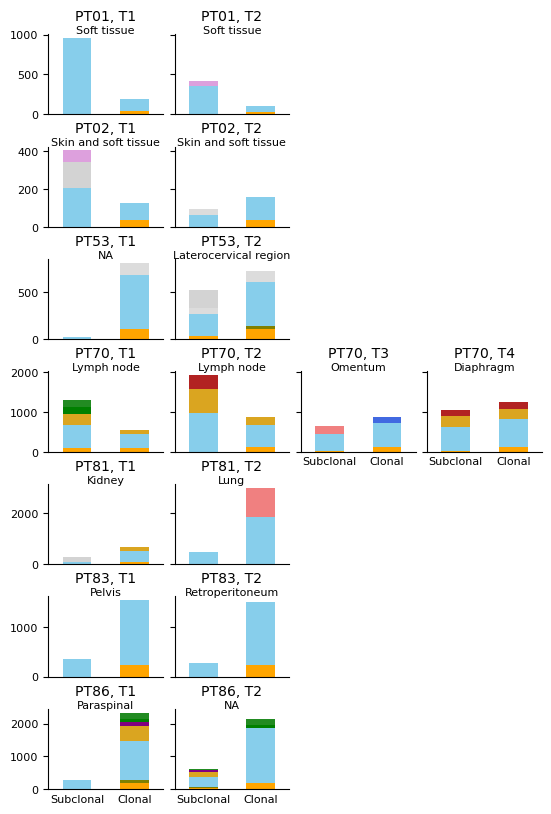

In [50]:
df1 = pd.DataFrame()
df2 = pd.DataFrame()
for sample in samples_list:
    df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    df1 = pd.concat([df1,df],ignore_index=True)
    df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/subclonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
    df2 = pd.concat([df2,df],ignore_index=True)

sigs_col = sorted([s for s in df1.columns if s.startswith('SBS')],key=lambda x: cosmic_sigs.index(x))
df1 = df1[['Samples']+sigs_col]
sigs_col = sorted([s for s in df2.columns if s.startswith('SBS')],key=lambda x: cosmic_sigs.index(x))
df2 = df2[['Samples']+sigs_col]

df2 = pd.merge(df2,df1[['Samples']],how='outer')
df2.fillna(0,inplace=True)
df2.sort_values('Samples',inplace=True)
df2.reset_index(inplace=True)
df2.index = df2['Samples']
df2.drop(['index','Samples'],inplace=True,axis=1)
df2 = df2.reindex(paired_samples)

df1.index = df1['Samples']
df1.drop(['Samples'],inplace=True,axis=1)
df1 = df1.reindex(paired_samples)

fig = plt.figure(figsize=(8,10), dpi=100)
gs = gridspec.GridSpec(len(sorted_paired_pts),5, hspace=0.4, wspace=0.1)

all_colors_dict = {}

x=0
n=1
for pt in sorted_paired_pts:
    y=0
    if pt == 'PMC01':
        tumors = ['_t3','_t4','_t2','_t1']
    else:
        tumors = ['_t1','_t2']
    for t in tumors:
        sample_id = pt + t
        df_clonal = df1[df1.index==sample_id]
        df_clonal['clonality'] = 'Clonal'
        df_subclonal = df2[df2.index==sample_id]
        df_subclonal['clonality'] = 'Subclonal'
        df_all = pd.concat([df_subclonal,df_clonal])
        df_all.index = df_all['clonality']
        sigs = list([s for s in df_all.columns if s.startswith('SBS')])
        colors_dict,colors_list = color_sigs(sigs)
        all_colors_dict = all_colors_dict | colors_dict
        sigs_dict = dict(df_all.sum())
        exclude_sigs = [s for s in sigs_dict.keys() if sigs_dict[s]==0]
        cols = [col for col in df_all.columns if col not in exclude_sigs]
        if y == 0:
            ax = fig.add_subplot(gs[x,y])
        else:
            ax = fig.add_subplot(gs[x,y],sharex=ax,sharey=ax)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        df_all[cols].plot.bar(ax=ax,stacked=True,color=colors_dict,legend=False)
        if pt == 'PMC01':
            sample_id_final = samples_final_ids_dict[pt]
            title = sample_id_final +', T' + str(n) 
            subtitle = sample_loc_dict[pt+'_t'+t[-1]]
            n =  n +1
        else:
            sample_id_final = samples_final_ids_dict[pt]
            title = sample_id_final+', T'+t[-1]
            subtitle = sample_loc_dict[pt+'_t'+t[-1]]
        ax.set_title(title,size=10,pad=10)
        ax.text(0.5,1.05,s=subtitle,size=8,ha='center',va='center',transform=ax.transAxes)
        ax.set_xlabel('')
        ax.set_xticks([0,1],labels=['Subclonal','Clonal'],rotation=0,size=8)
        # y_max = int(df_all[sigs].sum(axis=1).max())
        # ax.set_yticks(np.linspace(0,y_max,4),size=12)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x',size=0)
        y = y +1
    x = x+1
    
plt.savefig('plots/mut_signatures_multiple_samples_cases_clonal_subclonal.svg', bbox_inches='tight',format='svg')

### PADYZI, sample with 2 germlines, and high N of SBS17a and SBS17b mutations

,SBS1,SBS5,SBS17a,SBS17b,clonality
Samples,,,,,
PADYZI,12,203,0,0,Subclonal
PADYZI,0,0,275,876,Clonal


<Figure size 200x200 with 0 Axes>

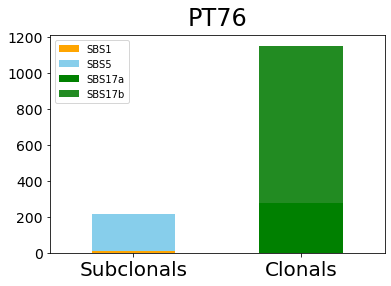

In [51]:

sample = 'PADYZI'
df1 = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
df2 = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/subclonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')

sigs_col = sorted([s for s in df1.columns if s.startswith('SBS')],key=lambda x: cosmic_sigs.index(x))
df1 = df1[['Samples']+sigs_col]
sigs_col = sorted([s for s in df2.columns if s.startswith('SBS')],key=lambda x: cosmic_sigs.index(x))
df2 = df2[['Samples']+sigs_col]

df1['clonality'] = 'Clonal'
df2['clonality'] = 'Subclonal'

df2 = pd.merge(df2,df1[['Samples']],how='outer')
df2.fillna(0,inplace=True)
df2.sort_values('Samples',inplace=True)
df2.reset_index(inplace=True)
df2.index = df2['Samples']
df2.drop(['index','Samples'],inplace=True,axis=1)

df1.index = df1['Samples']
df1.drop(['Samples'],inplace=True,axis=1)

plt.figure(figsize=(2,2), dpi=100)

all_colors_dict = {}

df_all = pd.concat([df2,df1])
display(df_all)
df_all.index = df_all['clonality']
sigs = list([s for s in df_all.columns if s.startswith('SBS')])
colors_dict,colors_list = color_sigs(sigs)
all_colors_dict = all_colors_dict | colors_dict
sigs_dict = dict(df_all.sum())
exclude_sigs = [s for s in sigs_dict.keys() if sigs_dict[s]==0]
cols = [col for col in df_all.columns if col not in exclude_sigs]
# plt.spines['right'].set_visible(False)
# plt.spines['top'].set_visible(False)
df_all[cols].plot.bar(stacked=True,color=colors_dict,legend=True)
pt_final = samples_final_ids_dict[sample]
plt.title(pt_final,size=24,pad=10)
plt.xlabel('')
plt.xticks([0,1],labels=['Subclonals','Clonals'],rotation=0,size=20)
plt.tick_params(axis='y', labelsize=14)

plt.savefig('plots/mut_signatures_PT76_2germline_SBS17_clonal_subclonal.svg', bbox_inches='tight',format='svg')
plt.show()
